# 01 — OLS, Gauss-Markov and Causal Identification
**Key references:** Gauss (1809) · Markov (1900) · Frisch-Waugh-Lovell (1933) · Wooldridge (2010) · Greene (2012) · Angrist & Pischke (2009) · Rosenbaum & Rubin (1983)

---

## Narrative thread

The underlying question is always the same: **how much does $x$ cause $y$?**

OLS is the most widely used tool to answer it, but its validity as a causal estimator rests on one key assumption: that the error is uncorrelated with the regressors (MLR.4). This notebook follows a logical progression:

```
1. The problem:     selection bias prevents direct comparison of treated and controls
2. The solution:    CIA — conditioning on confounders restores comparability
3. The estimator:   OLS under linear CIA; FWL shows exactly what OLS is doing
4. The limit:       OVB when CIA fails; non-linearity when the relationship is curved
5. The guarantees:  Gauss-Markov (BLUE), sampling distribution, R²
```

---

## Notation

### Indices and dimensions

| Symbol | Definition |
|---|---|
| $i = 1, \ldots, n$ | Observation index |
| $k$ | Number of regressors (excluding constant) |
| $K = k + 1$ | Total number of parameters (including constant) |

### Variables and matrices

| Symbol | Definition |
|---|---|
| $y \in \mathbb{R}^n$ | Dependent variable vector |
| $X \in \mathbb{R}^{n \times K}$ | Regressor matrix (includes column of ones) |
| $\beta \in \mathbb{R}^K$ | Population parameter vector (unknown) |
| $u \in \mathbb{R}^n$ | Unobservable error vector |
| $\hat{\beta} = (X^\top X)^{-1}X^\top y$ | OLS estimator |
| $\hat{u}_i = y_i - x_i\hat{\beta}$ | Residual for observation $i$ |
| $Y_i(1),\, Y_i(0)$ | Potential outcomes with/without treatment (Rubin, 1974) |
| $D_i \in \{0,1\}$ | Treatment indicator |
| $\tau_i = Y_i(1) - Y_i(0)$ | Individual causal effect (never observable) |

### Sums of squares and fit

| Symbol | Name | Formula |
|---|---|---|
| $SST$ | Total | $\sum_i (y_i - \bar{y})^2$ |
| $SSE$ | Explained | $\sum_i (\hat{y}_i - \bar{y})^2$ |
| $SSR$ | Residual | $\sum_i \hat{u}_i^2$ |
| $R^2$ | Goodness of fit | $1 - SSR/SST$ |
| $\bar{R}^2$ | Adjusted | $1 - \frac{SSR/(n-K)}{SST/(n-1)}$ |

### Projections

| Symbol | Definition |
|---|---|
| $M_{X_2} = I - X_2(X_2^\top X_2)^{-1}X_2^\top$ | Annihilator matrix — removes the linear variation of $X_2$ |
| $\tilde{x}_1 = M_{X_2} x_1$ | Residual of $x_1$ on $X_2$: variation of $x_1$ linearly orthogonal to $X_2$ |

---

## Gauss-Markov assumptions

OLS minimizes $\|y - Xb\|^2 \implies \hat{\beta} = (X^\top X)^{-1}X^\top y$.

| # | Assumption | Formal condition | Consequence if violated |
|---|---|---|---|
| **MLR.1** | Linearity in parameters | $y = X\beta + u$ | Specification bias |
| **MLR.2** | Random sample | $(x_i, y_i)$ i.i.d. | Invalid inference |
| **MLR.3** | No perfect multicollinearity | $\text{rank}(X) = K$ | $(X^\top X)^{-1}$ does not exist |
| **MLR.4** | Zero conditional mean | $E[u \mid X] = 0$ | **Bias and inconsistency** |
| **MLR.5** | Homoskedasticity | $\text{Var}(u \mid X) = \sigma^2 I$ | Incorrect standard errors |
| **MLR.6** | Normality *(optional)* | $u \mid X \sim \mathcal{N}(0, \sigma^2 I)$ | Inexact t-tests in small $n$ |

> **Gauss-Markov theorem:** Under MLR.1-5, $\hat{\beta}$ is **BLUE** — the Best Linear Unbiased Estimator.

**MLR.4 is the causal assumption.** The others are technical conditions. When MLR.4 fails, $\hat{\beta}$ is biased and inconsistent — more data does not fix it. The rest of the notebook explains when MLR.4 holds and when it does not.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
    'font.size': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9, 'font.family': 'Optima',
})
np.random.seed(42)

# Ecuación de salarios tipo Mincer (Wooldridge, Example 3.1)
n = 1000
educ   = np.random.randint(8, 20, n).astype(float)
exper  = np.clip(np.random.normal(15, 8, n), 0, 45)
female = np.random.binomial(1, 0.45, n).astype(float)
u      = np.random.normal(0, 0.5, n)

log_wage = 1.0 + 0.10*educ + 0.04*exper - 0.0006*exper**2 - 0.20*female + u

df = pd.DataFrame({'log_wage': log_wage, 'educ': educ,
                   'exper': exper, 'exper2': exper**2, 'female': female})

X = sm.add_constant(df[['educ', 'exper', 'exper2', 'female']])
model = sm.OLS(df['log_wage'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     152.4
Date:                Mon, 29 Jun 2026   Prob (F-statistic):          1.11e-101
Time:                        04:02:33   Log-Likelihood:                -719.91
No. Observations:                1000   AIC:                             1450.
Df Residuals:                     995   BIC:                             1474.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9884      0.081     12.226      0.0

## Section 2 — FWL: what OLS does when it "controls"

Before understanding FWL, we need to understand why we need to control in the first place.

---

### The problem: selection bias

If you want to estimate the causal effect of education on wages, a naive comparison
$\bar{Y}_{\text{high educ}} - \bar{Y}_{\text{low educ}}$ is contaminated: people with more
education also tend to have more experience, different gender compositions, different family
backgrounds — all of which independently affect wages.

In the potential outcomes framework (Rubin, 1974):
$$E[Y \mid D=1] - E[Y \mid D=0] = \underbrace{E[Y(1) - Y(0) \mid D=1]}_{ATT} + \underbrace{E[Y(0) \mid D=1] - E[Y(0) \mid D=0]}_{\text{selection bias}}$$

The second term is the **selection bias**: the pre-existing difference in the baseline
outcome $Y(0)$ between treated and controls, which has nothing to do with the treatment.
This bias exists because treatment assignment is not random — it correlates with $X$.

---

### The solution: Conditional Independence Assumption (CIA)

The **CIA** (also called *unconfoundedness* or *ignorability*) was formalized by
Rosenbaum & Rubin (1983):

$$\boxed{Y(0) \perp D \mid X}$$

**Plain English:** once you condition on the observed covariates $X$, knowing whether
someone was treated tells you nothing additional about their untreated potential outcome $Y(0)$.
In other words, *conditional on $X$, treatment is as good as random*.

#### What CIA requires

CIA makes three implicit claims:

1. **All confounders are observed.** Every variable that affects both $D$ and $Y$ must
   be included in $X$. If there is even one unobserved confounder, CIA fails.

2. **The conditioning set $X$ is pre-treatment.** You cannot condition on variables
   caused by the treatment (colliders) — that opens new biases instead of closing them.

3. **Overlap (common support).** For every value of $X$, there must be both treated
   and untreated units: $0 < P(D=1 \mid X) < 1$. Without overlap, the counterfactual
   is extrapolated, not estimated.

#### What CIA gives you

Under CIA, within each cell of $X$, the selection bias disappears:
$$E[Y(0) \mid D=1, X] = E[Y(0) \mid D=0, X]$$

so the ATT is identified by comparing treated and controls at the same value of $X$:
$$ATT = E\bigl[E[Y \mid D=1, X] - E[Y \mid D=0, X] \mid D=1\bigr]$$

#### When CIA is plausible vs. when it is not

| Situation | CIA plausible? | Why |
|---|---|---|
| Randomized experiment (RCT) | Always | Randomization ensures $D \perp Y(0)$ unconditionally |
| Administrative data with rich controls | Sometimes | Depends on what drives selection into treatment |
| Self-selection on unobservables | No | E.g., ability bias in returns to education |
| Treatment based on a cutoff | Use RDD | CIA fails globally but holds locally at the threshold |
| Panel data with time-invariant confounders | Use DiD | Differencing removes fixed unobservables |

---

### OLS as an implementation of CIA under linearity

If we additionally assume that $E[Y \mid D, X]$ is linear:
$$E[Y \mid D, X] = \beta_0 + \beta_1 D + \beta_2 X$$

then OLS estimates $\beta_1$ directly. Under CIA + linearity:
$$\hat{\beta}_1^{OLS} \xrightarrow{p} ATT = ATE$$

The linearity assumption is what makes CIA *implementable* with a single regression.
If the true $E[Y \mid D, X]$ is nonlinear, OLS still estimates a weighted average of
the conditional effects, but it is no longer exactly the ATT — this is where
matching, IPW, and Double ML come in.

---

### FWL: the mechanics of how OLS implements CIA

**FWL** (Frisch, Waugh 1933; Lovell 1963) reveals the exact mechanism:
OLS does not "hold $X$ fixed" in a metaphysical sense — it literally removes the
linear variation of $X$ from both $D$ and $Y$, then correlates the residuals.

#### Why the residual is "what $X_2$ cannot linearly explain"

Regress $x_1$ on $x_2$:
$$x_1 = \hat{\gamma}\, x_2 + \tilde{x}_1$$

- $\hat{\gamma}\, x_2$: the part of $x_1$ that $x_2$ predicts linearly — shared variation.
- $\tilde{x}_1 = x_1 - \hat{\gamma}\, x_2$: the residual — what remains after $x_2$'s best linear attempt.

By the OLS first-order condition, this residual is **linearly orthogonal** to $x_2$:
$$\text{Cov}(\tilde{x}_1,\, x_2) = 0$$

All linear correlation between $x_1$ and $x_2$ has been absorbed into $\hat{\gamma}\, x_2$.
What remains in $\tilde{x}_1$ is variation in $x_1$ that is linearly independent of $x_2$.

> **Key precision:** orthogonality is only linear. If $x_1$ and $x_2$ have an unmodeled
> nonlinear relationship (e.g., $x_2^2$, $x_1 \cdot x_2$), $\tilde{x}_1$ can still be
> nonlinearly correlated with $x_2$ — so the "control" is incomplete. This is why we
> include `exper^2` in this notebook, and why Double ML (Chernozhukov et al., 2018)
> uses ML instead of OLS to residualize.

#### The three steps

**Step 1 — Residualize $x_1$ on controls $X_2$:**
$$\tilde{x}_1 = x_1 - \hat{\gamma} X_2 \qquad \text{Cov}(\tilde{x}_1, X_2) = 0$$
Variation in $x_1$ that $X_2$ cannot linearly explain.

**Step 2 — Residualize $y$ on controls $X_2$:**
$$\tilde{y} = y - \hat{\delta} X_2 \qquad \text{Cov}(\tilde{y}, X_2) = 0$$
Variation in $y$ that $X_2$ cannot linearly explain.

**Step 3 — Regress $\tilde{y}$ on $\tilde{x}_1$:**
$$\hat{\beta}_1^{FWL} = \frac{\text{Cov}(\tilde{x}_1,\, \tilde{y})}{\text{Var}(\tilde{x}_1)} = \hat{\beta}_1^{OLS}$$

Both residuals are linearly orthogonal to $X_2$. Their correlation captures only the
variation in $x_1$ that $X_2$ does not control — the *ceteris paribus* effect.

#### Formal proof

Model: $y = X_1\beta_1 + X_2\beta_2 + u$. Pre-multiply by $M_{X_2}$:
$$M_{X_2} y = M_{X_2} X_1 \beta_1 + \underbrace{M_{X_2} X_2}_{=\,0} \beta_2 + M_{X_2} u
\implies \tilde{y} = \tilde{X}_1 \beta_1 + \tilde{u}$$

OLS on this residualized regression gives $\hat{\beta}_1^{FWL} = \hat{\beta}_1^{OLS}$. $\square$

---

### When OLS/FWL is not enough

| Situation | Problem | Solution |
|---|---|---|
| CIA fails (unobserved confounder) | OVB — MLR.4 violated | IV, RDD, DiD |
| Nonlinear $x_1$-$X_2$ relationship | Incomplete control | Include transformations or use Double ML |
| $x_1$ and $X_2$ highly correlated | $\tilde{x}_1$ has low variance, high SE | More data, variable selection |

════════════════════════════════════════════════════════════
  Verificación FWL — tres formas de estimar β_educ
════════════════════════════════════════════════════════════
  Correlación BRUTA  educ → log_wage:  0.096372  ← confundida
  OLS completo       (4 regresores):   0.099207
  FWL residualizado  (y~ ~ educ~):       0.099207
  OLS completo ≡ FWL: diferencia =     8.33e-17
════════════════════════════════════════════════════════════

  Correlación bruta - FWL = -0.002835  ← esto es el OVB
  (exper y female "inflan" la correlación bruta)

  R² de regresión educ ~ controles: 0.0028
  → los controles explican el 0.3% de la variación de educ
  → el 99.7% restante es la variación "limpia" que usa FWL


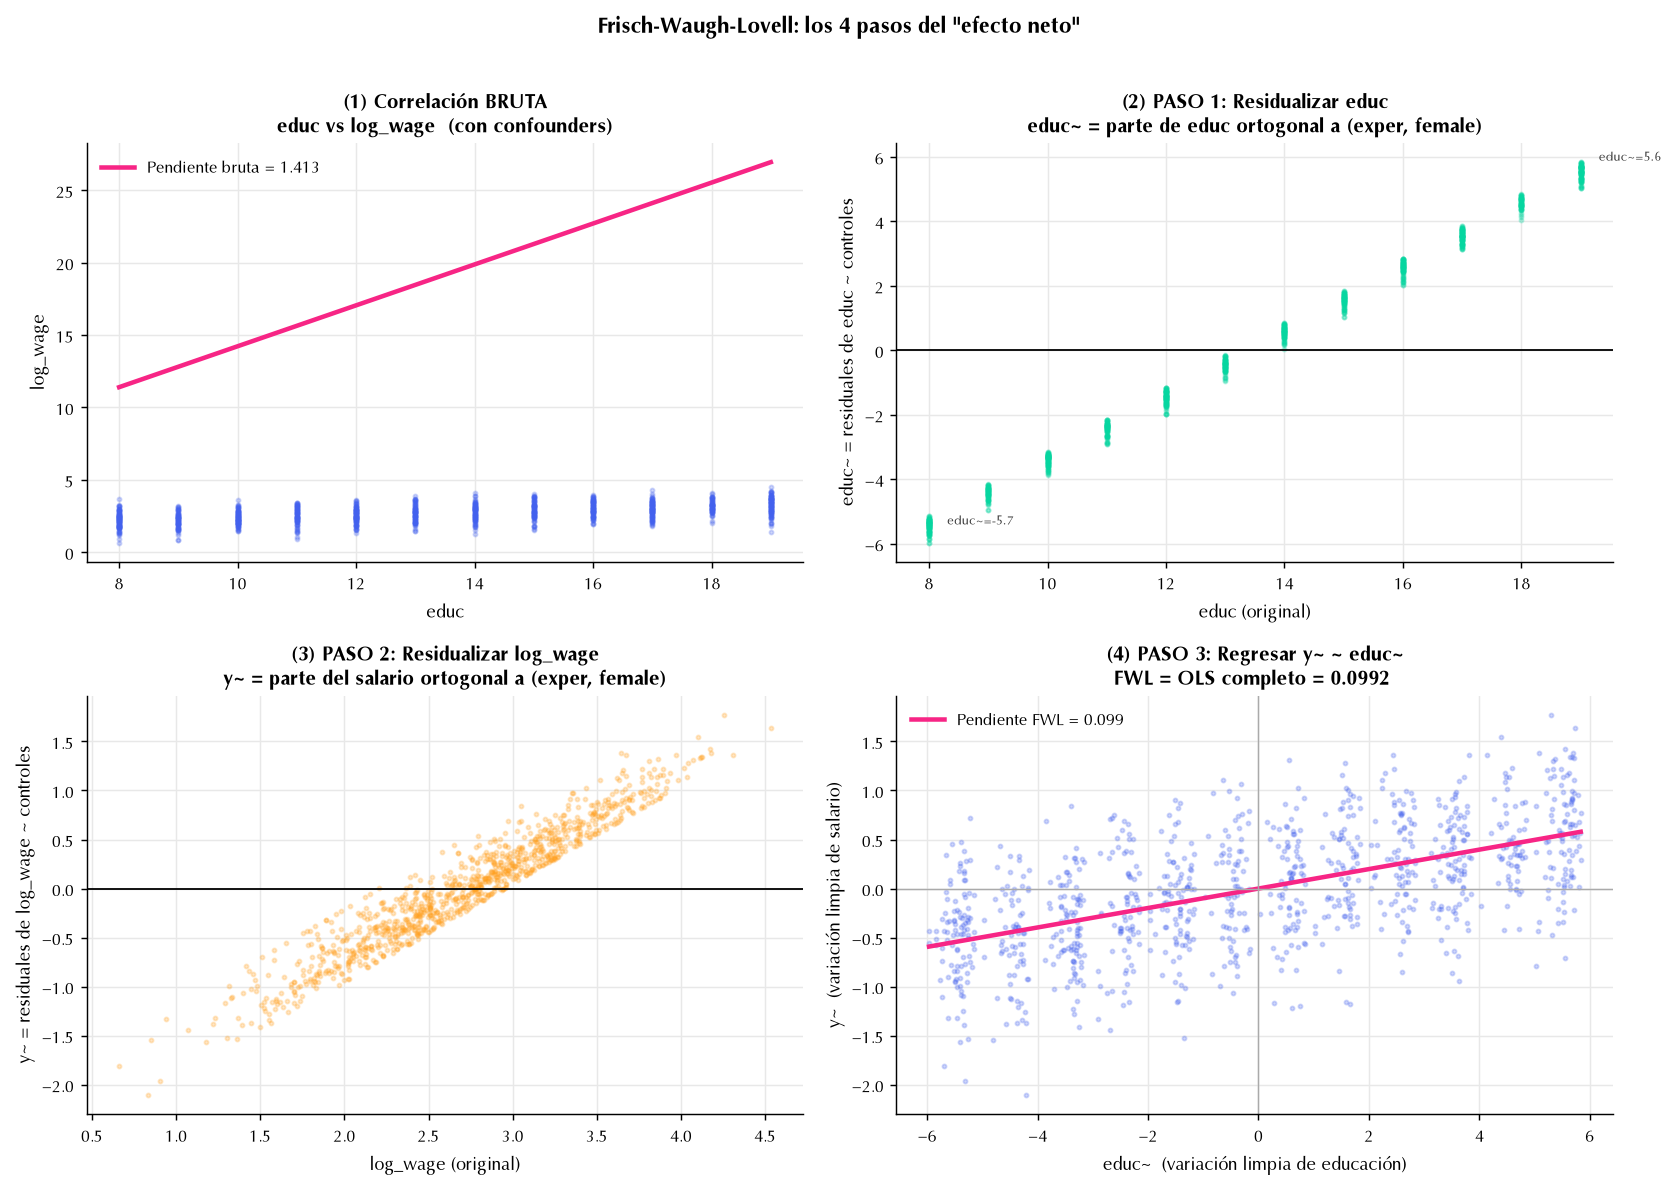

In [2]:
# ═══════════════════════════════════════════════════════════
# FWL — Demostración paso a paso
# ═══════════════════════════════════════════════════════════
# Objetivo: mostrar que β_educ en la regresión completa
#           es idéntico a la regresión simple de y~ sobre educ~
# ───────────────────────────────────────────────────────────

controls = sm.add_constant(df[['exper', 'exper2', 'female']])

# ── PASO 1: residualizar educ sobre los controles ─────────
# educ~ = M·educ = lo que la experiencia y el género NO explican de la educación
mod_educ   = sm.OLS(df['educ'], controls).fit()
educ_tilde = mod_educ.resid   # educ~

# ── PASO 2: residualizar log_wage sobre los controles ─────
# y~ = M·y = lo que la experiencia y el género NO explican del salario
mod_y   = sm.OLS(df['log_wage'], controls).fit()
y_tilde = mod_y.resid          # y~

# ── PASO 3: regresar y~ sobre educ~ ─────────────────────────
# Sin constante — los residuales ya tienen media exactamente 0
beta_fwl = sm.OLS(y_tilde, educ_tilde).fit().params.iloc[0]
beta_ols  = model.params['educ']
beta_bruta, *_ = stats.linregress(df['educ'], df['log_wage'])[:2]

print('═' * 60)
print('  Verificación FWL — tres formas de estimar β_educ')
print('═' * 60)
print(f'  Correlación BRUTA  educ → log_wage:  {beta_bruta:.6f}  ← confundida')
print(f'  OLS completo       (4 regresores):   {beta_ols:.6f}')
print(f'  FWL residualizado  (y~ ~ educ~):       {beta_fwl:.6f}')
print(f'  OLS completo ≡ FWL: diferencia =     {abs(beta_ols - beta_fwl):.2e}')
print('═' * 60)
print()
print(f'  Correlación bruta - FWL = {beta_bruta - beta_fwl:.6f}  ← esto es el OVB')
print(f'  (exper y female "inflan" la correlación bruta)')

# ── DIAGNÓSTICO: ¿cuánto explican los controles de educ? ──
r2_educ = mod_educ.rsquared
print(f'\n  R² de regresión educ ~ controles: {r2_educ:.4f}')
print(f'  → los controles explican el {r2_educ*100:.1f}% de la variación de educ')
print(f'  → el {(1-r2_educ)*100:.1f}% restante es la variación "limpia" que usa FWL')

# ── VISUALIZACIÓN ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Panel 1: correlación bruta (confundida)
ax = axes[0, 0]
ax.scatter(df['educ'], df['log_wage'], s=5, alpha=0.25, color='#4361ee')
x_r = np.linspace(df['educ'].min(), df['educ'].max(), 100)
b0_bruta, b1_bruta, *_ = stats.linregress(df['educ'], df['log_wage'])
ax.plot(x_r, b0_bruta + b1_bruta*x_r, color='#f72585', linewidth=2.5,
        label=f'Pendiente bruta = {b1_bruta:.3f}')
ax.set_xlabel('educ'); ax.set_ylabel('log_wage')
ax.set_title('(1) Correlación BRUTA\neduc vs log_wage  (con confounders)')
ax.legend(fontsize=9)

# Panel 2: paso 1 — residualizar educ
ax = axes[0, 1]
ax.scatter(df['educ'], educ_tilde, s=5, alpha=0.25, color='#06d6a0')
x_r2 = np.linspace(df['educ'].min(), df['educ'].max(), 100)
b_aux, b0_aux, *_ = stats.linregress(df['educ'], educ_tilde)
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('educ (original)')
ax.set_ylabel('educ~ = residuales de educ ~ controles')
ax.set_title('(2) PASO 1: Residualizar educ\neduc~ = parte de educ ortogonal a (exper, female)')
# Añadir dos ejemplos extremos
for q in [0.05, 0.95]:
    val = df['educ'].quantile(q)
    idx = (df['educ'] - val).abs().idxmin()
    ax.annotate(f'educ~={educ_tilde[idx]:.1f}',
                xy=(df['educ'][idx], educ_tilde[idx]),
                xytext=(df['educ'][idx]+0.3, educ_tilde[idx]+0.3),
                fontsize=7, color='#333')

# Panel 3: paso 2 — residualizar y
ax = axes[1, 0]
ax.scatter(df['log_wage'], y_tilde, s=5, alpha=0.25, color='#ff9f1c')
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('log_wage (original)')
ax.set_ylabel('y~ = residuales de log_wage ~ controles')
ax.set_title('(3) PASO 2: Residualizar log_wage\ny~ = parte del salario ortogonal a (exper, female)')

# Panel 4: FWL — efecto neto limpio
ax = axes[1, 1]
ax.scatter(educ_tilde, y_tilde, s=5, alpha=0.25, color='#4361ee')
x_fwl = np.linspace(educ_tilde.min(), educ_tilde.max(), 100)
ax.plot(x_fwl, beta_fwl * x_fwl, color='#f72585', linewidth=2.5,
        label=f'Pendiente FWL = {beta_fwl:.3f}')
ax.axhline(0, color='#aaa', linewidth=0.8)
ax.axvline(0, color='#aaa', linewidth=0.8)
ax.set_xlabel('educ~  (variación limpia de educación)')
ax.set_ylabel('y~  (variación limpia de salario)')
ax.set_title(f'(4) PASO 3: Regresar y~ ~ educ~\nFWL = OLS completo = {beta_fwl:.4f} ')
ax.legend(fontsize=9)

plt.suptitle('Frisch-Waugh-Lovell: los 4 pasos del "efecto neto"',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Section 3 — OVB: when CIA fails

### OVB is selection bias in regression language

When CIA fails because a confounder $z$ is unobserved, it passes into the error $u$,
so $\text{Cov}(x_1, u) \neq 0$ — violating MLR.4.

Let the true (long) model be:
$$y = \beta_1 x_1 + \beta_2 z + u \qquad E[u \mid x_1, z] = 0 \quad \text{(CIA holds with } z \text{ included)}$$

If we estimate the short model omitting $z$:
$$y = \tilde{\beta}_1 x_1 + \tilde{u} \qquad \tilde{u} = \beta_2 z + u$$

The auxiliary regression of $z$ on $x_1$ gives $\delta = \text{Cov}(x_1,z)/\text{Var}(x_1)$. Then:
$$E[\hat{\tilde{\beta}}_1] = \beta_1 + \underbrace{\beta_2}_{\gamma} \cdot \underbrace{\delta}_{\text{Cov}(x_1,z)/\text{Var}(x_1)} = \beta_1 + \text{OVB}$$

**OVB has the same structure as selection bias** — it is the product of two channels
that must both be active:

$$\text{OVB} = \underbrace{\beta_2}_{\text{effect of }z\text{ on }y} \times \underbrace{\delta}_{\text{correlation of }x_1\text{ with }z}$$

If $z$ does not affect $y$ ($\beta_2 = 0$), or if $z$ is uncorrelated with $x_1$ ($\delta = 0$),
there is no bias — even though $z$ is omitted.

### Direction of bias

| Sign of $\gamma$ | Sign of $\delta$ | OVB | Direction |
|---|---|---|---|
| $+$ | $+$ | $+$ | Overestimates $\beta_1$ |
| $+$ | $-$ | $-$ | Underestimates $\beta_1$ |
| $-$ | $+$ | $-$ | Underestimates $\beta_1$ |
| $-$ | $-$ | $+$ | Overestimates $\beta_1$ |

### In the Mincer example: omitting `female`

- $\gamma < 0$: women earn less — `female` has a negative effect on wages
- $\delta < 0$: in this sample, women have slightly less education
- $\text{OVB} = (-)(-)= (+)$: the short model **overestimates** the return to education

### The causal chain

OVB violates MLR.4 because the omitted confounder enters the error:
$$E[u \mid x_1] = E[\beta_2 z \mid x_1] = \beta_2 \delta x_1 \neq 0$$

The solutions in the rest of this course are all strategies to restore $E[u \mid X] = 0$
without needing to observe $z$:
- **IV** (notebook 02): use an instrument that moves $x_1$ but is uncorrelated with $z$
- **RDD** (notebook 03): compare units just either side of a threshold where $z$ is smooth
- **DiD** (notebook 10): differencing over time eliminates fixed unobserved confounders
- **Matching/IPW** (notebook 05): reweight to balance observed $X$ between treated and controls

In [3]:
# Demostrar OVB: omitir 'female' de la regresión
X_short = sm.add_constant(df[['educ', 'exper', 'exper2']])
model_short = sm.OLS(df['log_wage'], X_short).fit()

# Fórmula OVB: γ × δ
gamma = model.params['female']   # efecto de female sobre log_wage (largo)
delta = sm.OLS(df['female'],     X_short).fit().params['educ']  # educ → female

ovb_formula  = gamma * delta
ovb_observed = model_short.params['educ'] - model.params['educ']

print('Sesgo por Variable Omitida — Wooldridge (2010, p. 90)')
print(f'  β_educ (modelo largo, con female):   {model.params["educ"]:.6f}')
print(f'  β_educ (modelo corto, sin female):   {model_short.params["educ"]:.6f}')
print(f'  Sesgo observado:                     {ovb_observed:.6f}')
print(f'  Fórmula OVB (γ × δ):                {ovb_formula:.6f}')
print(f'  ¿Coinciden? {abs(ovb_observed - ovb_formula) < 1e-10}')
print()
print(f'  γ (female → log_wage): {gamma:.4f}  δ (educ → female): {delta:.4f}')
print('  Dirección del sesgo: mujeres tienen menos educación (δ<0) y menor salario (γ<0)')
print('  → δ<0, γ<0 → sesgo positivo: modelo corto sobreestima el retorno a la educación')

Sesgo por Variable Omitida — Wooldridge (2010, p. 90)
  β_educ (modelo largo, con female):   0.099207
  β_educ (modelo corto, sin female):   0.098804
  Sesgo observado:                     -0.000403
  Fórmula OVB (γ × δ):                -0.000403
  ¿Coinciden? True

  γ (female → log_wage): -0.1661  δ (educ → female): 0.0024
  Dirección del sesgo: mujeres tienen menos educación (δ<0) y menor salario (γ<0)
  → δ<0, γ<0 → sesgo positivo: modelo corto sobreestima el retorno a la educación


## Section 4 — Sampling properties of $\hat{\beta}$

Assuming CIA holds (MLR.4 satisfied), OLS identifies the causal parameter.
But what are its statistical properties — how precisely does it estimate it?

### Unbiasedness, consistency, and efficiency

| Property | Definition | Required assumptions |
|---|---|---|
| **Unbiasedness** | $E[\hat{\beta}] = \beta$ for any $n$ | MLR.1-4 |
| **Consistency** | $\hat{\beta} \xrightarrow{p} \beta$ as $n \to \infty$ | MLR.1-4 (sufficient: $E[x_i u_i]=0$) |
| **Efficiency (BLUE)** | Minimum variance among linear unbiased estimators | MLR.1-5 |

### Exact vs asymptotic distribution

**Under MLR.1-6** (with normality of $u$):
$$\hat{\beta} \sim \mathcal{N}(\beta,\; \sigma^2 (X^\top X)^{-1})$$
Exact distribution in finite samples — t-tests are valid for any $n$.

**Under MLR.1-5** (without normality):
$$\frac{\hat{\beta}_j - \beta_j}{\widehat{SE}(\hat{\beta}_j)} \xrightarrow{d} \mathcal{N}(0, 1) \quad \text{as } n \to \infty$$
By the CLT — t-tests are asymptotically valid even without normality of $u$.

### Variance of the estimator

$$\text{Var}(\hat{\beta}) = \sigma^2 (X^\top X)^{-1} \qquad \hat{\sigma}^2 = \frac{SSR}{n-K}$$

Variance increases when: (a) $\sigma^2$ is large (noisy data), (b) $(X^\top X)^{-1}$
is large (little variation in $X$ or high multicollinearity), (c) $n$ is small.

### Monte Carlo simulation: numerical verification of theoretical properties

Monte Carlo generates $B$ samples from the same DGP and verifies that:
- The mean of $\hat{\beta}$ converges to $\beta$ (unbiasedness)
- The spread converges to $\sigma^2(X^\top X)^{-1}$ (theoretical variance)
- The shape of the distribution is normal (exact under MLR.6, asymptotic under MLR.1-5)

Distribución muestral de β̂_educ (Monte Carlo, B=2000)
  Valor verdadero β_educ:        0.100000
  Media simulada:                0.100247  (≈ insesgado)
  Varianza simulada:             0.00002118
  Varianza teórica σ²(X⊤X)⁻¹:  0.00002019


/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_28286/3064517717.py:31: UserWarning: Glyph 946 (\N{GREEK SMALL LETTER BETA}) missing from font(s) Optima.
  plt.tight_layout()
/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_28286/3064517717.py:31: UserWarning: Glyph 963 (\N{GREEK SMALL LETTER SIGMA}) missing from font(s) Optima.
  plt.tight_layout()
/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_28286/3064517717.py:31: UserWarning: Glyph 8868 (\N{DOWN TACK}) missing from font(s) Optima.
  plt.tight_layout()
/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_28286/3064517717.py:31: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Optima.
  plt.tight_layout()
/Volumes/SSD_Gabo/proyectos/growth-analytics/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 946 (\N{GREEK SMALL LETTER BETA}) missing from font(s) Optima.
  fig.canvas.print_figure(bytes_io, **kw)
/Volumes/SSD_Gabo/proyectos/growth-an

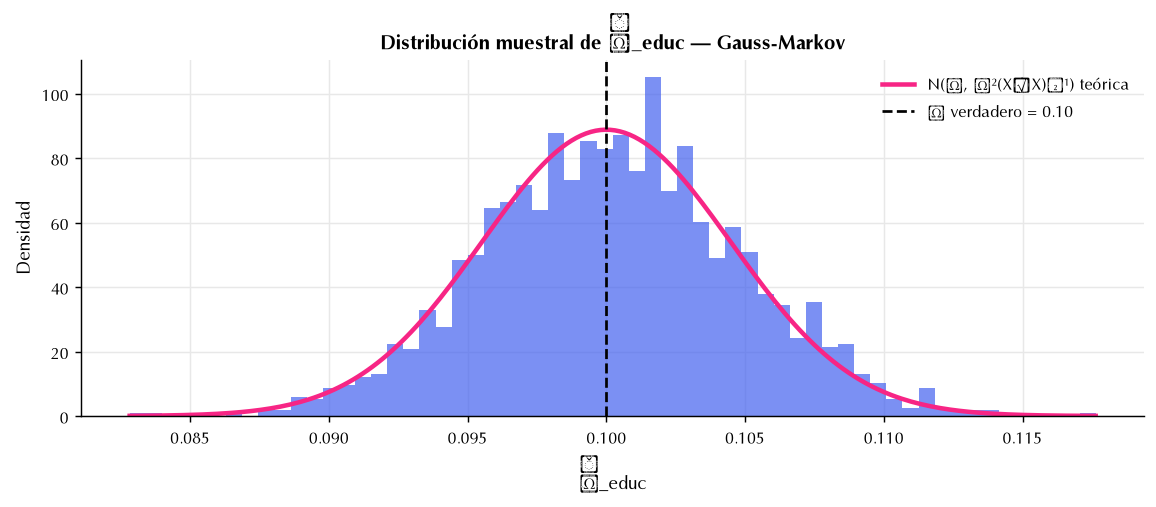

In [4]:
# Simulación Monte Carlo de la distribución de β̂
B = 2000   # repeticiones
beta_educ_sim = np.zeros(B)

for b in range(B):
    u_b = np.random.normal(0, 0.5, n)
    y_b = 1.0 + 0.10*educ + 0.04*exper - 0.0006*exper**2 - 0.20*female + u_b
    m   = sm.OLS(y_b, X).fit()
    beta_educ_sim[b] = m.params['educ']

# Varianza teórica de OLS
sigma2  = 0.5**2
XtX_inv = np.linalg.inv(X.values.T @ X.values)
var_educ_theory = sigma2 * XtX_inv[1, 1]   # índice 1 = educ (0 = const)

print('Distribución muestral de β̂_educ (Monte Carlo, B=2000)')
print(f'  Valor verdadero β_educ:        0.100000')
print(f'  Media simulada:                {beta_educ_sim.mean():.6f}  (≈ insesgado)')
print(f'  Varianza simulada:             {beta_educ_sim.var():.8f}')
print(f'  Varianza teórica σ²(X⊤X)⁻¹:  {var_educ_theory:.8f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(beta_educ_sim, bins=60, color='#4361ee', alpha=0.7, density=True)
x_range = np.linspace(beta_educ_sim.min(), beta_educ_sim.max(), 200)
ax.plot(x_range, stats.norm.pdf(x_range, 0.10, np.sqrt(var_educ_theory)),
        color='#f72585', linewidth=2.5, label='N(β, σ²(X⊤X)⁻¹) teórica')
ax.axvline(0.10, color='black', linewidth=1.5, linestyle='--', label='β verdadero = 0.10')
ax.set_xlabel('β̂_educ'); ax.set_ylabel('Densidad')
ax.set_title('Distribución muestral de β̂_educ — Gauss-Markov')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Section 5 — $R^2$ and the goodness-of-fit trap

With valid CIA and correctly specified OLS, $\hat{\beta}$ identifies the causal effect.
$R^2$ measures something different: how well the linear model predicts $y$ in-sample.

$$R^2 = \frac{SSE}{SST} = 1 - \frac{SSR}{SST} = \left[\text{Corr}(y, \hat{y})\right]^2$$

### What $R^2$ does NOT measure

- **Not causality.** An $R^2 = 0.9$ with an endogenous regressor is still biased.
- **Not economic importance.** A coefficient can be highly significant with $R^2 = 0.05$.
- **Not model validity.** High $R^2$ is achievable with a misspecified functional form.

> **Angrist & Pischke (2009, p. 76):** "A high $R^2$ is neither necessary nor sufficient
> for a regression to have a causal interpretation."

### The mechanical problem: $R^2$ never decreases when adding variables

$$R^2_{K+1} \geq R^2_K \quad \text{always}$$

Adding a regressor can never worsen in-sample fit — at worst its coefficient is zero.
But it consumes a degree of freedom and can introduce bias if you inadvertently
condition on a collider (a variable caused by the treatment).

### Adjusted $R^2$: penalizing for parsimony

$$\bar{R}^2 = 1 - \frac{SSR/(n-K)}{SST/(n-1)}$$

Can decrease when adding an irrelevant variable. But it is still not a measure of
causal quality — only of penalized in-sample fit.

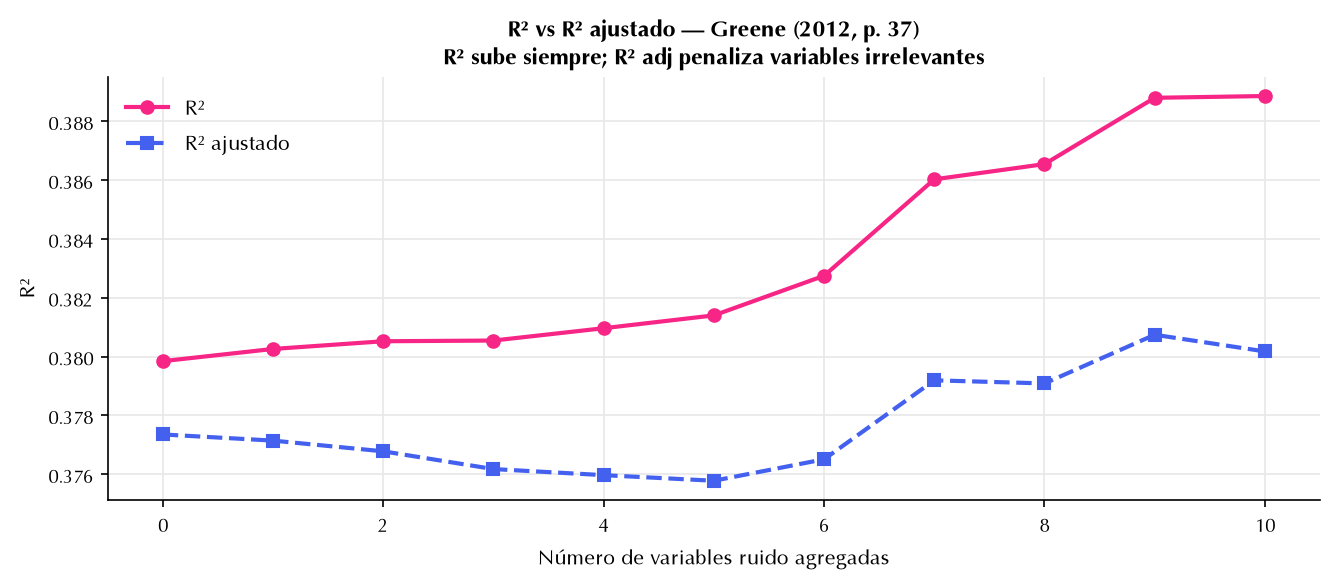

R² ajustado: penaliza la pérdida de grados de libertad
  R² con 0 vars ruido: 0.3798  adj: 0.3774
  R² con 10 vars ruido: 0.3889  adj: 0.3802


In [5]:
# Mostrar que R² sube mecánicamente al agregar variables irrelevantes
noise_vars = pd.DataFrame(np.random.normal(0, 1, (n, 10)),
                          columns=[f'noise_{i}' for i in range(10)])
df_ext = pd.concat([df, noise_vars], axis=1)

r2_list, r2_adj_list, k_list = [], [], []
base_vars = ['educ', 'exper', 'exper2', 'female']

for k in range(11):
    noise_cols = [f'noise_{i}' for i in range(k)]
    X_k = sm.add_constant(df_ext[base_vars + noise_cols])
    m_k = sm.OLS(df_ext['log_wage'], X_k).fit()
    r2_list.append(m_k.rsquared)
    r2_adj_list.append(m_k.rsquared_adj)
    k_list.append(k)

fig, ax = plt.subplots(figsize=(9, 4), dpi=150)
ax.plot(k_list, r2_list,     'o-', color='#f72585', linewidth=2, markersize=6, label='R²')
ax.plot(k_list, r2_adj_list, 's--', color='#4361ee', linewidth=2, markersize=6, label='R² ajustado')
ax.set_xlabel('Número de variables ruido agregadas')
ax.set_ylabel('R²')
ax.set_title('R² vs R² ajustado — Greene (2012, p. 37)\nR² sube siempre; R² adj penaliza variables irrelevantes')
ax.legend()
plt.tight_layout()
plt.show()

print('R² ajustado: penaliza la pérdida de grados de libertad')
print(f'  R² con 0 vars ruido: {r2_list[0]:.4f}  adj: {r2_adj_list[0]:.4f}')
print(f'  R² con 10 vars ruido: {r2_list[10]:.4f}  adj: {r2_adj_list[10]:.4f}')

## Summary

### The narrative thread in one table

| Section | Question | Tool | Key assumption |
|---|---|---|---|
| 1. Setup | When is OLS causally valid? | Gauss-Markov | MLR.4: $E[u|X]=0$ |
| 2. FWL | What does OLS do when it "controls"? | Residualization | CIA + linearity |
| 3. OVB | What happens when CIA fails? | $\gamma\delta$ formula | — (CIA violated) |
| 4. Distribution | How precisely does $\hat{\beta}$ estimate $\beta$? | Monte Carlo | MLR.1-5 (or +6) |
| 5. $R^2$ | Does $R^2$ measure causal quality? | No. | — |

### Core technical results

| Result | Formula |
|---|---|
| OLS estimator | $\hat{\beta} = (X^\top X)^{-1}X^\top y$ |
| BLUE (Gauss-Markov) | Minimum variance under MLR.1-5 |
| OLS variance | $\sigma^2(X^\top X)^{-1}$ |
| OVB formula | $E[\hat{\tilde{\beta}}_1] = \beta_1 + \gamma\delta$ |
| FWL theorem | $\hat{\beta}_1^{OLS} = \hat{\beta}_1^{FWL}$ exactly |

### The causal identification decision tree

```
Goal: estimate ATT = E[Y(1) - Y(0) | D=1]
        |
        Does CIA hold?  Y(0) perp D | X
        (all confounders observed, pre-treatment, overlap satisfied)
        |
       YES                              NO
        |                               |
   OLS with controls X          Need another strategy
   (FWL residualizes D on X)         |
   (valid only under linearity)       +-- Unobserved confounder + instrument  -> IV/2SLS    (nb 02)
                                      +-- Assignment based on a cutoff         -> RDD        (nb 03)
                                      +-- Time-invariant unobservables         -> DiD        (nb 10)
                                      +-- Selection on observables, nonlinear  -> Matching   (nb 05)
                                      +-- CIA + nonlinear nuisance             -> Double ML  (nb 09)
```

### When does OLS fail?

| Violation | Assumption broken | Solution |
|---|---|---|
| Omitted confounder correlated with $D$ | MLR.4 | IV, RDD, DiD, matching |
| Reverse causality ($y$ causes $x$) | MLR.4 | IV with exogenous instrument |
| Unmodeled nonlinearity | MLR.1 | Transformations, Double ML |
| Heteroskedasticity | MLR.5 | HC-robust standard errors |
| Few clusters in panel data | MLR.2 | Cluster-robust SE, wild bootstrap |

**Next:** `02_instrumental_variables.ipynb` — when MLR.4 fails due to endogeneity
and we cannot observe the confounder.